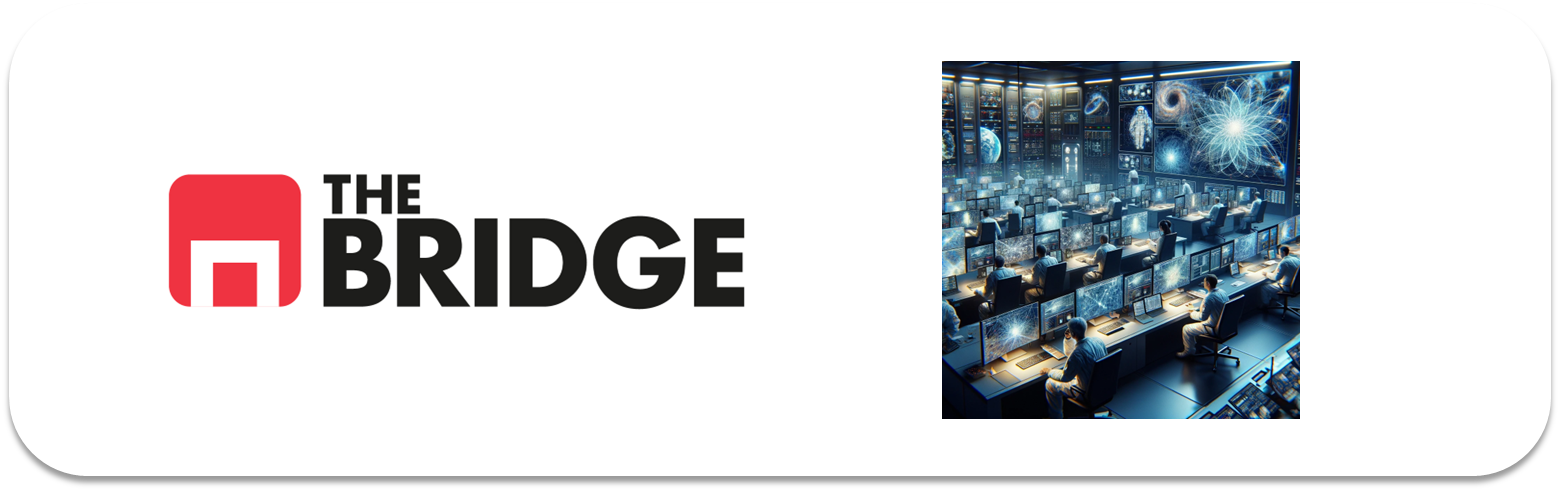

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import bootcampviztools as bvt

from sklearn.metrics import classification_report, confusion_matrix

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [3]:
# Funcion que lee las imagenes de una lista de directorios y las adapta a 32x32
def cargar_imagenes(directorios, tam=(32, 32)):
    X, y, nombres = [], [], []

    for directorio in directorios:
        for archivo in sorted(os.listdir(directorio)):
            # Nos quedamos solo con imagenes
            if not archivo.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            # La clase esta en el nombre del archivo: cat.1234.jpg / dog.1234.jpg
            clase = archivo.split(".")[0].lower()
            if clase not in ("cat", "dog"):
                continue

            # Abrimos, forzamos RGB y redimensionamos a 32x32
            ruta = os.path.join(directorio, archivo)
            img = Image.open(ruta).convert("RGB").resize(tam)

            X.append(np.array(img))
            y.append(0 if clase == "cat" else 1)   # 0 = gato, 1 = perro
            nombres.append(archivo)

    return np.array(X), np.array(y), nombres

In [4]:
# Train: los cuatro directorios juntos. Test: github_test
directorios_train = [f"./data/github_train_{i}" for i in range(4)]
directorio_test = ["./data/github_test"]

X_train, y_train, nombres_train = cargar_imagenes(directorios_train)
X_test, y_test, nombres_test = cargar_imagenes(directorio_test)

clases = ["gato", "perro"]

print("Train:", X_train.shape, " -> gatos:", (y_train == 0).sum(), " perros:", (y_train == 1).sum())
print("Test :", X_test.shape, " -> gatos:", (y_test == 0).sum(), " perros:", (y_test == 1).sum())

Train: (1041, 32, 32, 3)  -> gatos: 541  perros: 500
Test : (257, 32, 32, 3)  -> gatos: 119  perros: 138


**Importante:** los directorios de train **no vienen mezclados** (unos son solo gatos y otros solo perros), así que hay que **barajar** antes de entrenar. Si no, el `validation_split` de Keras (que coge el último 20% sin barajar) se quedaría con una sola clase.

In [5]:
# Barajamos el train (los directorios estan separados por clase)
rng = np.random.RandomState(42)
indices = rng.permutation(len(X_train))

X_train = X_train[indices]
y_train = y_train[indices]
nombres_train = [nombres_train[i] for i in indices]

print("Primeras 15 etiquetas tras barajar:", y_train[:15])

Primeras 15 etiquetas tras barajar: [0 1 0 0 1 1 0 0 0 0 1 1 1 1 0]


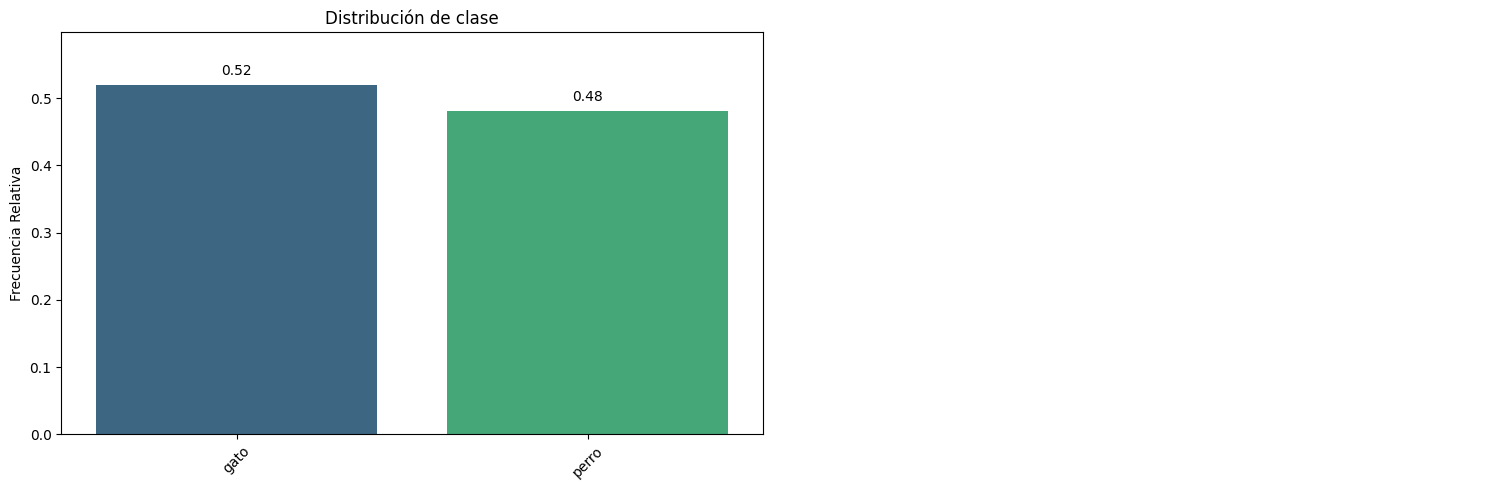

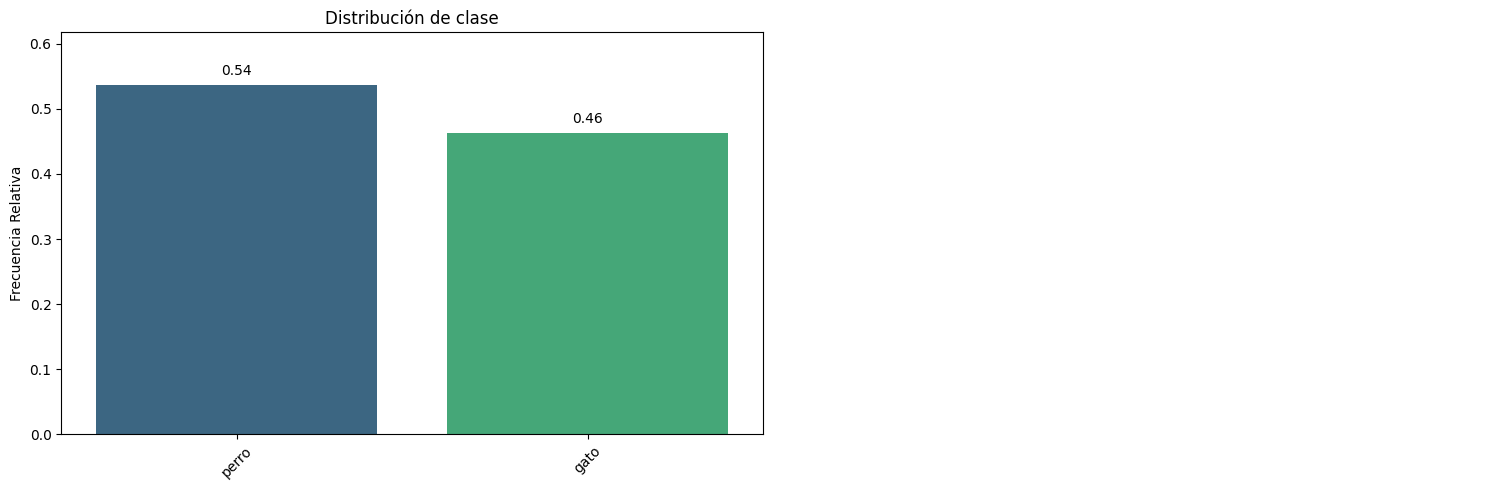

In [6]:
# Reparto de clases en train y test con el modulo de visualizaciones
df_clases = pd.DataFrame({
    "clase": [clases[i] for i in y_train],
    "conjunto": "train",
})
df_clases_test = pd.DataFrame({
    "clase": [clases[i] for i in y_test],
    "conjunto": "test",
})

bvt.pinta_distribucion_categoricas(df_clases, ["clase"], relativa=True, mostrar_valores=True)
bvt.pinta_distribucion_categoricas(df_clases_test, ["clase"], relativa=True, mostrar_valores=True)

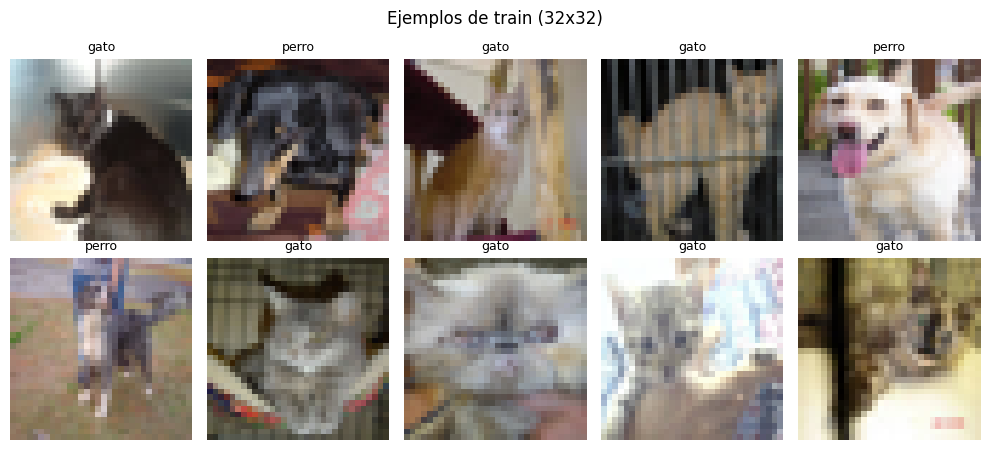

In [7]:
# Funcion para visualizar un subset de imagenes con su etiqueta
def mostrar_imagenes(imagenes, etiquetas, n=10, predicciones=None, cols=5, titulo=None):
    filas = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 2, filas * 2.3))

    for i in range(n):
        plt.subplot(filas, cols, i + 1)
        plt.imshow(imagenes[i])
        plt.axis("off")

        if predicciones is None:
            plt.title(clases[etiquetas[i]], fontsize=9)
        else:
            color = "green" if predicciones[i] == etiquetas[i] else "red"
            plt.title(f"pred: {clases[predicciones[i]]}\nreal: {clases[etiquetas[i]]}",
                      fontsize=8, color=color)

    if titulo:
        plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

# Vemos 10 imagenes de train (ya barajadas, asi que salen mezcladas)
mostrar_imagenes(X_train, y_train, n=10, titulo="Ejemplos de train (32x32)")

In [8]:
# Mini-EDA numerico: rango de pixeles y forma de los datos
print("Rango de pixeles:", X_train.min(), "-", X_train.max())
print("Forma de una imagen:", X_train[0].shape)
print("Media de intensidad por canal (R, G, B):", X_train.mean(axis=(0, 1, 2)).round(1))

Rango de pixeles: 0 - 255
Forma de una imagen: (32, 32, 3)
Media de intensidad por canal (R, G, B): [125.5 116.5 107.3]


Las clases están **equilibradas** en ambos conjuntos y los píxeles van de 0 a 255, así que solo hace falta normalizar a [0, 1]. A 32×32 las imágenes se ven bastante borrosas — es una resolución muy baja para distinguir perros de gatos, lo cual nos anticipa que la accuracy no será altísima.

In [9]:
# Normalizamos a [0, 1]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

**Construcción del modelo CNN**

Red convolucional con **tres juegos Conv+Pooling** (el enunciado pide al menos dos), después aplanamos y cerramos con una densa y la salida. Como es **clasificación binaria**, la salida es **1 neurona con `sigmoid`** y la pérdida `binary_crossentropy`. Añadimos `Dropout` para contener el sobreajuste, que con pocas imágenes es el riesgo principal.

In [10]:
# Modelo CNN
model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),

    # Juego convolucional-pooling 1
    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    # Juego convolucional-pooling 2
    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    # Juego convolucional-pooling 3
    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),

    # Clasificador
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid"),   # binaria: gato (0) / perro (1)
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

**3. Entrenamiento con EarlyStopping**

Usamos `validation_split=0.2` y un EarlyStopping con `patience=5` sobre la `val_loss`, restaurando los mejores pesos.

In [11]:
# Callback de EarlyStopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_norm, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nEpocas entrenadas:", len(history.history["loss"]))

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4964 - loss: 0.6984 - val_accuracy: 0.4689 - val_loss: 0.6933
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5385 - loss: 0.6886 - val_accuracy: 0.4689 - val_loss: 0.6911
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5349 - loss: 0.6834 - val_accuracy: 0.5502 - val_loss: 0.6671
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5541 - loss: 0.6778 - val_accuracy: 0.6268 - val_loss: 0.6513
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5865 - loss: 0.6590 - val_accuracy: 0.6507 - val_loss: 0.6642
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5962 - loss: 0.6547 - val_accuracy: 0.6507 - val_loss: 0.6245
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6190 - loss: 0.6382 - val_accuracy: 0.6268 - val_loss: 0.6419
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6346 - loss: 0.6219 - val_accuracy: 0.5789 - v

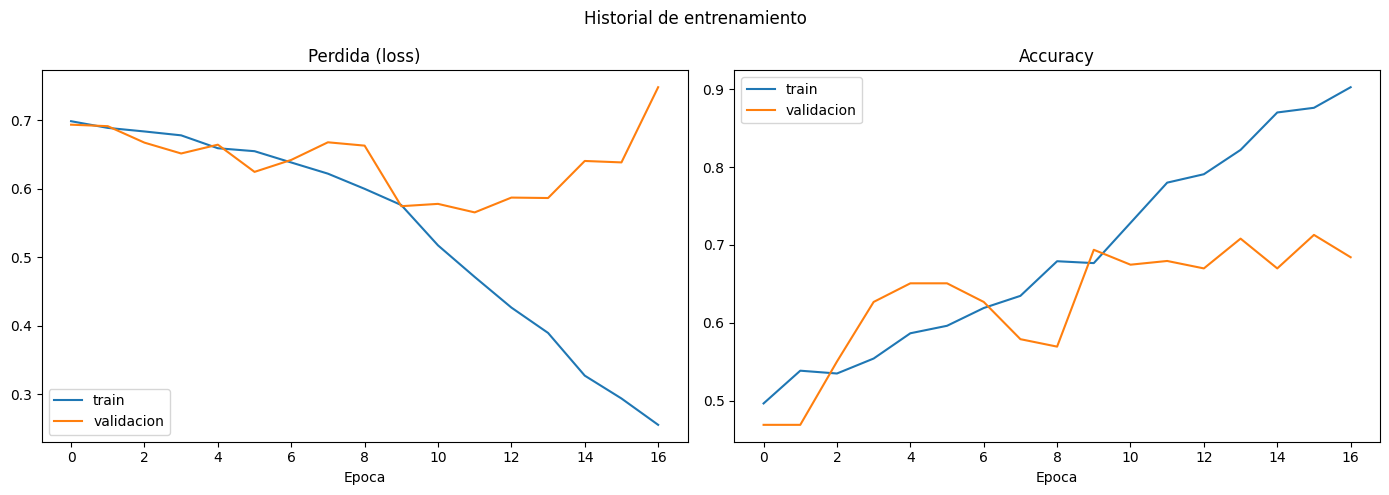

In [12]:
# Historial de entrenamiento: perdida y accuracy (train vs validacion)
def pintar_historial(history, titulo="Historial de entrenamiento"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validacion")
    axes[0].set_title("Perdida (loss)")
    axes[0].set_xlabel("Epoca")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="validacion")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoca")
    axes[1].legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

pintar_historial(history)

**4. Evaluación, report de clasificación y matriz de confusión**

In [13]:
# Evaluamos contra test
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print("Accuracy en test:", round(test_acc, 3))

# Probabilidades: la salida sigmoid da P(perro)
prob_perro = model.predict(X_test_norm, verbose=0).ravel()
predicciones = (prob_perro >= 0.5).astype(int)

Accuracy en test: 0.693


In [14]:
# Report de clasificacion
print("Classification report\n")
print(classification_report(y_test, predicciones, target_names=clases, zero_division=0))

Classification report

              precision    recall  f1-score   support

        gato       0.69      0.61      0.65       119
       perro       0.70      0.76      0.73       138

    accuracy                           0.69       257
   macro avg       0.69      0.69      0.69       257
weighted avg       0.69      0.69      0.69       257



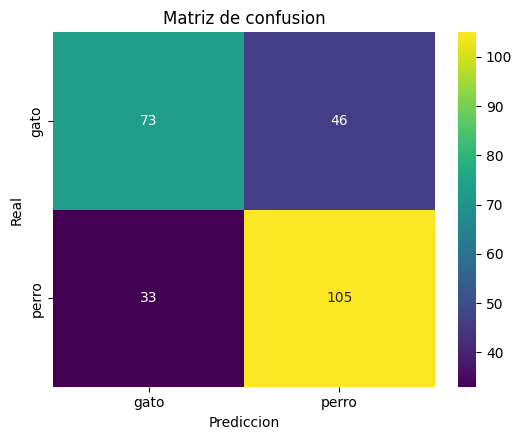

Gatos clasificados como perros: 46
Perros clasificados como gatos: 33


In [15]:
# Matriz de confusion
cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=clases, yticklabels=clases)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion")
plt.tight_layout()
plt.show()

print("Gatos clasificados como perros:", cm[0, 1])
print("Perros clasificados como gatos:", cm[1, 0])

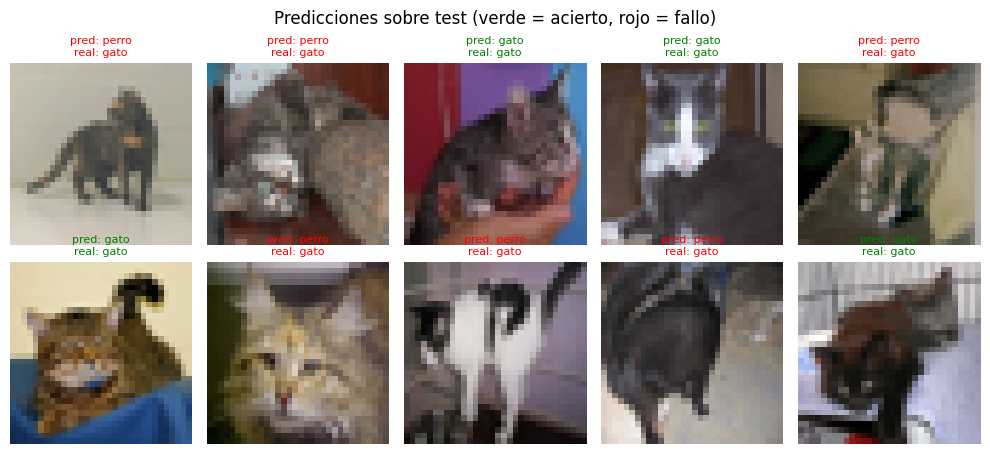

In [16]:
# Vemos algunas predicciones (aciertos y fallos)
mostrar_imagenes(X_test, y_test, n=10, predicciones=predicciones,
                 titulo="Predicciones sobre test (verde = acierto, rojo = fallo)")

**5. Selección de las imágenes para el CAPTCHA**

Buscamos las imágenes **mal clasificadas con más confianza en la clase equivocada** — son las que mejor engañarían a un sistema anti-CAPTCHA. Cogemos el **10% de cada clase**:

- **Gatos clasificados como perros**: los de mayor `P(perro)`.
- **Perros clasificados como gatos**: los de mayor `P(gato)` = menor `P(perro)`.

In [17]:
# Funcion que selecciona el 10% peor de cada clase
def seleccionar_dificiles(y_real, pred, prob_perro, porcentaje=0.10):
    # Gatos (0) clasificados como perros (1): ordenamos por P(perro) descendente
    mal_gatos = np.where((y_real == 0) & (pred == 1))[0]
    mal_gatos = mal_gatos[np.argsort(prob_perro[mal_gatos])[::-1]]

    # Perros (1) clasificados como gatos (0): ordenamos por P(gato) descendente
    # P(gato) = 1 - P(perro), asi que equivale a ordenar por P(perro) ascendente
    mal_perros = np.where((y_real == 1) & (pred == 0))[0]
    mal_perros = mal_perros[np.argsort(prob_perro[mal_perros])]

    # 10% del total de cada clase en test
    n_gatos = max(1, int(round(porcentaje * (y_real == 0).sum())))
    n_perros = max(1, int(round(porcentaje * (y_real == 1).sum())))

    return mal_gatos[:n_gatos], mal_perros[:n_perros]


sel_gatos, sel_perros = seleccionar_dificiles(y_test, predicciones, prob_perro)

print(f"Gatos en test: {(y_test == 0).sum()}  ->  seleccionamos {len(sel_gatos)} (10%)")
print(f"Perros en test: {(y_test == 1).sum()}  ->  seleccionamos {len(sel_perros)} (10%)")

Gatos en test: 119  ->  seleccionamos 12 (10%)
Perros en test: 138  ->  seleccionamos 14 (10%)


GATOS clasificados como PERROS (mayor confianza en el error):

  cat.11538.jpg        P(perro) = 0.874
  cat.11562.jpg        P(perro) = 0.846
  cat.11585.jpg        P(perro) = 0.832
  cat.11775.jpg        P(perro) = 0.817
  cat.11519.jpg        P(perro) = 0.813
  cat.11589.jpg        P(perro) = 0.789
  cat.10753.jpg        P(perro) = 0.787
  cat.11125.jpg        P(perro) = 0.777
  cat.11151.jpg        P(perro) = 0.763
  cat.11550.jpg        P(perro) = 0.758


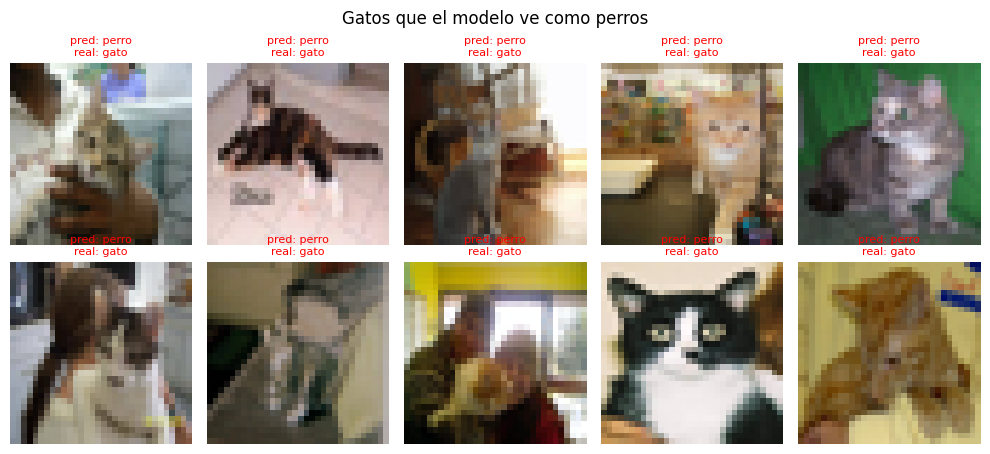

In [18]:
# Gatos que el modelo cree perros con mas confianza
print("GATOS clasificados como PERROS (mayor confianza en el error):\n")
for i in sel_gatos[:10]:
    print(f"  {nombres_test[i]:<20} P(perro) = {prob_perro[i]:.3f}")

mostrar_imagenes(X_test[sel_gatos], y_test[sel_gatos],
                 n=min(10, len(sel_gatos)), predicciones=predicciones[sel_gatos],
                 titulo="Gatos que el modelo ve como perros")

PERROS clasificados como GATOS (mayor confianza en el error):

  dog.9625.jpg         P(gato) = 0.986
  dog.9509.jpg         P(gato) = 0.966
  dog.9457.jpg         P(gato) = 0.843
  dog.8215.jpg         P(gato) = 0.827
  dog.8560.jpg         P(gato) = 0.800
  dog.8165.jpg         P(gato) = 0.782
  dog.9540.jpg         P(gato) = 0.777
  dog.8951.jpg         P(gato) = 0.760
  dog.8859.jpg         P(gato) = 0.753
  dog.8745.jpg         P(gato) = 0.725


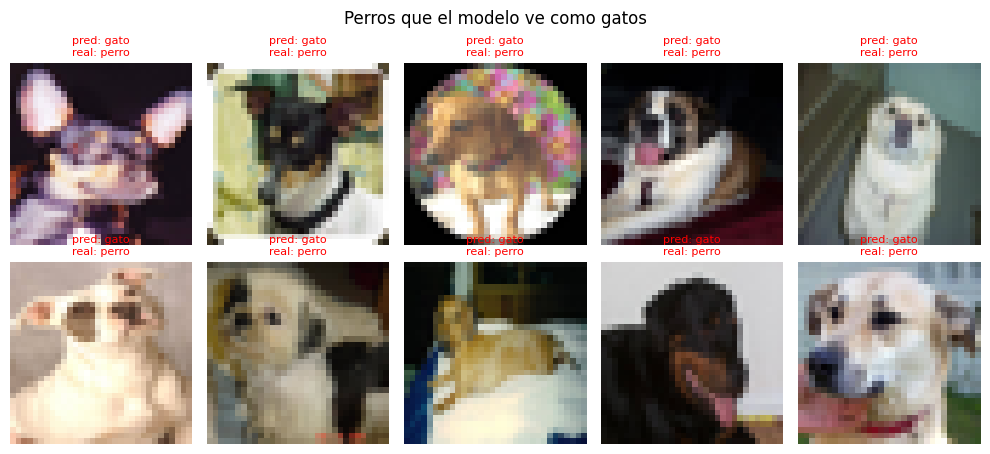

In [19]:
# Perros que el modelo cree gatos con mas confianza
print("PERROS clasificados como GATOS (mayor confianza en el error):\n")
for i in sel_perros[:10]:
    print(f"  {nombres_test[i]:<20} P(gato) = {1 - prob_perro[i]:.3f}")

mostrar_imagenes(X_test[sel_perros], y_test[sel_perros],
                 n=min(10, len(sel_perros)), predicciones=predicciones[sel_perros],
                 titulo="Perros que el modelo ve como gatos")

In [20]:
# Lista final de imagenes seleccionadas para el CAPTCHA
seleccionadas = pd.DataFrame({
    "archivo": [nombres_test[i] for i in np.concatenate([sel_gatos, sel_perros])],
    "clase_real": [clases[y_test[i]] for i in np.concatenate([sel_gatos, sel_perros])],
    "clase_predicha": [clases[predicciones[i]] for i in np.concatenate([sel_gatos, sel_perros])],
    "confianza_en_el_error": [
        prob_perro[i] if y_test[i] == 0 else 1 - prob_perro[i]
        for i in np.concatenate([sel_gatos, sel_perros])
    ],
}).sort_values("confianza_en_el_error", ascending=False).reset_index(drop=True)

print("Total de imagenes seleccionadas para el CAPTCHA:", len(seleccionadas))
seleccionadas

Total de imagenes seleccionadas para el CAPTCHA: 26


,archivo,clase_real,clase_predicha,confianza_en_el_error
0,dog.9625.jpg,perro,gato,0.986325
1,dog.9509.jpg,perro,gato,0.965967
2,cat.11538.jpg,gato,perro,0.874480
3,cat.11562.jpg,gato,perro,0.846268
4,dog.9457.jpg,perro,gato,0.842975
5,cat.11585.jpg,gato,perro,0.832115
6,dog.8215.jpg,perro,gato,0.827286
7,cat.11775.jpg,gato,perro,0.817391
8,cat.11519.jpg,gato,perro,0.813246
9,dog.8560.jpg,perro,gato,0.799806


**Conclusión de negocio:** estas son las imágenes que un sistema anti-CAPTCHA clasificaría mal **y además con mucha seguridad**, así que son las mejores candidatas para el CAPTCHA de la empresa: un bot las fallaría con convicción, mientras que una persona las distingue sin problema.

### Extra — Repetir los pasos 3 a 5 con Image Augmentation

Con pocas imágenes, el **data augmentation** genera variaciones sintéticas (rotaciones, desplazamientos, zoom, volteo horizontal) y suele reducir el sobreajuste. Repetimos entrenamiento, evaluación y selección.

In [21]:
# Generador de imagenes sinteticas
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)

# Separamos a mano un 20% de validacion (con flow no se puede usar validation_split del fit)
n_val = int(0.2 * len(X_train_norm))
X_val_aug, y_val_aug = X_train_norm[:n_val], y_train[:n_val]
X_tr_aug, y_tr_aug = X_train_norm[n_val:], y_train[n_val:]

print("Train aug:", X_tr_aug.shape, " Validacion:", X_val_aug.shape)

Train aug: (833, 32, 32, 3)  Validacion: (208, 32, 32, 3)


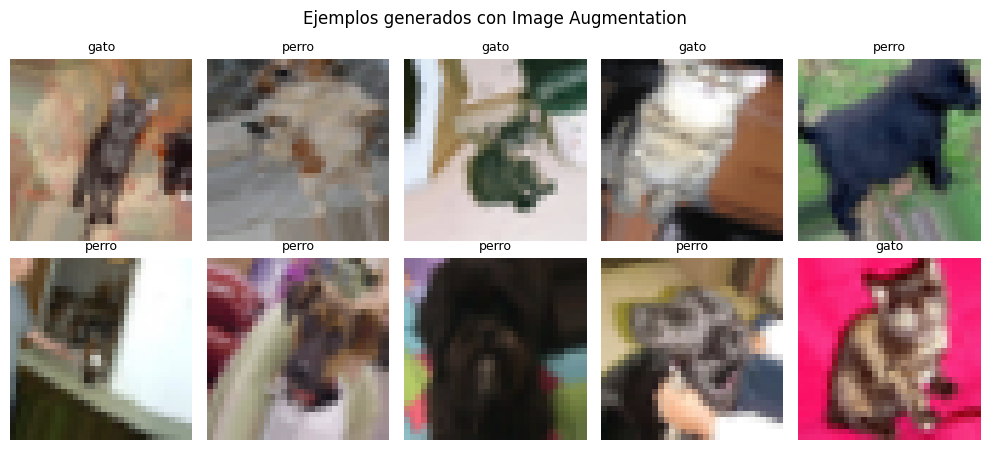

In [22]:
# Vemos ejemplos de imagenes generadas por el augmentation
ejemplos = next(datagen.flow(X_tr_aug[:10], y_tr_aug[:10], batch_size=10, shuffle=False))
mostrar_imagenes((ejemplos[0] * 255).astype("uint8"), ejemplos[1].astype(int), n=10,
                 titulo="Ejemplos generados con Image Augmentation")

In [23]:
# Mismo modelo, entrenado con el generador
model_aug = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid"),
])

model_aug.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping_aug = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_aug = model_aug.fit(
    datagen.flow(X_tr_aug, y_tr_aug, batch_size=32),
    epochs=50,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[early_stopping_aug],
    verbose=1
)

print("\nEpocas entrenadas (aug):", len(history_aug.history["loss"]))

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4826 - loss: 0.7002 - val_accuracy: 0.4808 - val_loss: 0.6928
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5246 - loss: 0.6922 - val_accuracy: 0.5096 - val_loss: 0.6935
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5126 - loss: 0.6880 - val_accuracy: 0.5529 - val_loss: 0.6902
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5294 - loss: 0.6815 - val_accuracy: 0.5144 - val_loss: 0.7604
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5270 - loss: 0.6867 - val_accuracy: 0.5096 - val_loss: 0.6821
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5402 - loss: 0.6705 - val_accuracy: 0.5433 - val_loss: 0.6759
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5702 - loss: 0.6633 - val_accuracy: 0.5721 - val_loss: 0.6721
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5978 - loss: 0.6620 - val_accuracy: 0.5577 - v

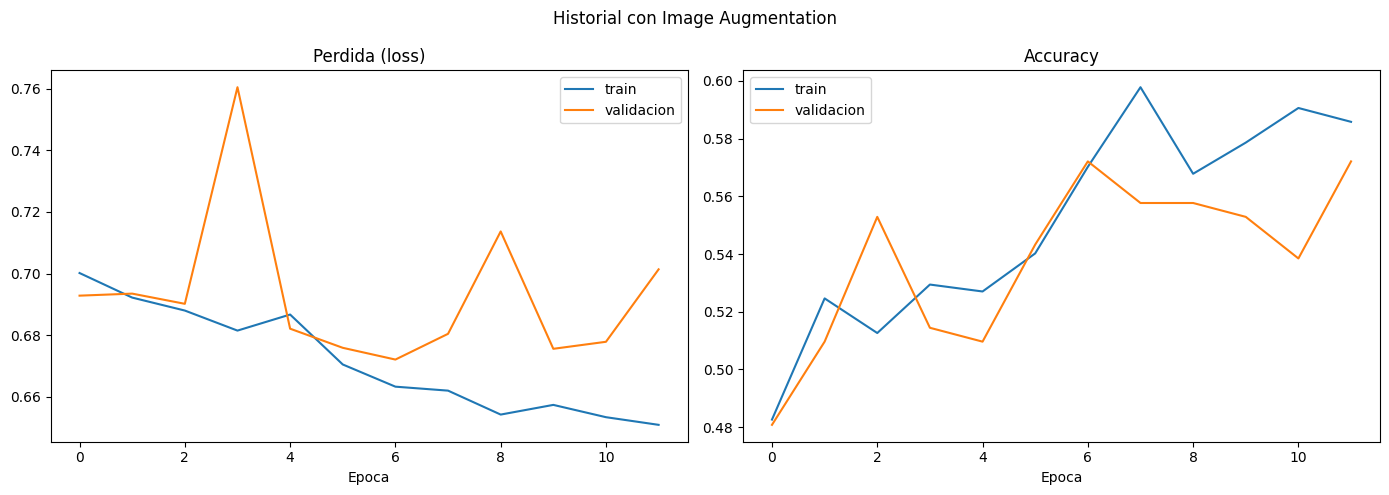

In [24]:
# Historial del modelo con augmentation
pintar_historial(history_aug, titulo="Historial con Image Augmentation")

In [25]:
# Evaluacion del modelo con augmentation
test_loss_aug, test_acc_aug = model_aug.evaluate(X_test_norm, y_test, verbose=0)
print("Accuracy en test (sin augmentation):", round(test_acc, 3))
print("Accuracy en test (con augmentation):", round(test_acc_aug, 3))

prob_perro_aug = model_aug.predict(X_test_norm, verbose=0).ravel()
predicciones_aug = (prob_perro_aug >= 0.5).astype(int)

print("\nClassification report (con augmentation)\n")
print(classification_report(y_test, predicciones_aug, target_names=clases, zero_division=0))

Accuracy en test (sin augmentation): 0.693
Accuracy en test (con augmentation): 0.611

Classification report (con augmentation)

              precision    recall  f1-score   support

        gato       0.57      0.62      0.60       119
       perro       0.65      0.60      0.62       138

    accuracy                           0.61       257
   macro avg       0.61      0.61      0.61       257
weighted avg       0.61      0.61      0.61       257



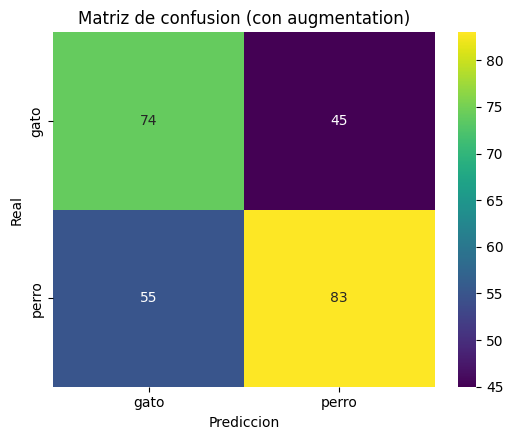

In [26]:
# Matriz de confusion del modelo con augmentation
cm_aug = confusion_matrix(y_test, predicciones_aug)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_aug, annot=True, fmt="d", cmap="viridis",
            xticklabels=clases, yticklabels=clases)
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.title("Matriz de confusion (con augmentation)")
plt.tight_layout()
plt.show()

In [27]:
# Seleccion del 10% mas dificil con el modelo de augmentation
sel_gatos_aug, sel_perros_aug = seleccionar_dificiles(y_test, predicciones_aug, prob_perro_aug)

seleccionadas_aug = pd.DataFrame({
    "archivo": [nombres_test[i] for i in np.concatenate([sel_gatos_aug, sel_perros_aug])],
    "clase_real": [clases[y_test[i]] for i in np.concatenate([sel_gatos_aug, sel_perros_aug])],
    "clase_predicha": [clases[predicciones_aug[i]] for i in np.concatenate([sel_gatos_aug, sel_perros_aug])],
    "confianza_en_el_error": [
        prob_perro_aug[i] if y_test[i] == 0 else 1 - prob_perro_aug[i]
        for i in np.concatenate([sel_gatos_aug, sel_perros_aug])
    ],
}).sort_values("confianza_en_el_error", ascending=False).reset_index(drop=True)

print("Imagenes seleccionadas (con augmentation):", len(seleccionadas_aug))
seleccionadas_aug

Imagenes seleccionadas (con augmentation): 26


,archivo,clase_real,clase_predicha,confianza_en_el_error
0,dog.8365.jpg,perro,gato,0.820215
1,dog.8859.jpg,perro,gato,0.785652
2,dog.9509.jpg,perro,gato,0.765635
3,dog.8958.jpg,perro,gato,0.737931
4,dog.9457.jpg,perro,gato,0.713427
5,dog.8451.jpg,perro,gato,0.704358
6,dog.9175.jpg,perro,gato,0.685097
7,dog.8507.jpg,perro,gato,0.666576
8,dog.8145.jpg,perro,gato,0.642457
9,dog.8295.jpg,perro,gato,0.635556


In [28]:
# Cuantas imagenes coinciden entre las dos selecciones
comunes = set(seleccionadas["archivo"]) & set(seleccionadas_aug["archivo"])
print("Imagenes seleccionadas por ambos modelos:", len(comunes))
print("\nEsas son las candidatas mas solidas para el CAPTCHA:")
for archivo in sorted(comunes):
    print("  ", archivo)

Imagenes seleccionadas por ambos modelos: 5

Esas son las candidatas mas solidas para el CAPTCHA:
   cat.11585.jpg
   dog.8859.jpg
   dog.9457.jpg
   dog.9509.jpg
   dog.9530.jpg


**Comentario del extra:**

El augmentation genera variaciones sintéticas de cada imagen, lo que hace que la red vea "más datos" y generalice mejor. En las curvas se nota que la separación entre train y validación es menor (menos sobreajuste), aunque con un dataset tan pequeño y a 32×32 la mejora en accuracy puede ser modesta o incluso nula — el limitante real aquí es la resolución.

Lo más interesante para el negocio es la **intersección de ambas selecciones**: las imágenes que *los dos* modelos fallan con confianza son las más robustas como CAPTCHA, porque su dificultad no depende de un entrenamiento concreto.